In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

## Preprocessing

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df['Income'] = df['Income'].fillna(df['Income'].mean())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [ ]:
## Year Birth -> age

df['age'] = 2026 - df['Year_Birth']

In [ ]:
## categorizing education values

print(df['Education'].value_counts())

df['Education'] = df['Education'].replace({
    "Graduation" : "Graduate",
    "PhD" : "Post Graduate", "Master" : "Post Graduate",
    "2n Cycle" : "Undergraduate", "Basic" : "Undergraduate"
})

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [19]:
## categorizing marital status values

print(df['Marital_Status'].value_counts())

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [13]:
## kidhome and teenhome to one feature

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [26]:
## Customer joining date to days

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

ref_date = df['Dt_Customer'].max()

df['Tenure_Days'] = (ref_date - df['Dt_Customer']).dt.days

In [17]:
## all spending in one feature

df['Total_Spends'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [27]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Total_Children', 'Total_Spends',
       'Living_With', 'Tenure_Days'],
      dtype='str')

## Drop Columns

In [28]:
cols = ['ID', 'Year_Birth', 'Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [29]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Children,Total_Spends,Living_With,Tenure_Days
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,0,1617,Alone,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,2,27,Alone,0
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,0,776,Partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,1,53,Partner,0
4,Post Graduate,58293.0,94,5,5,3,6,5,0,0,45,1,422,Partner,0


In [30]:
df_cleaned.shape

(2240, 15)

## Outliers

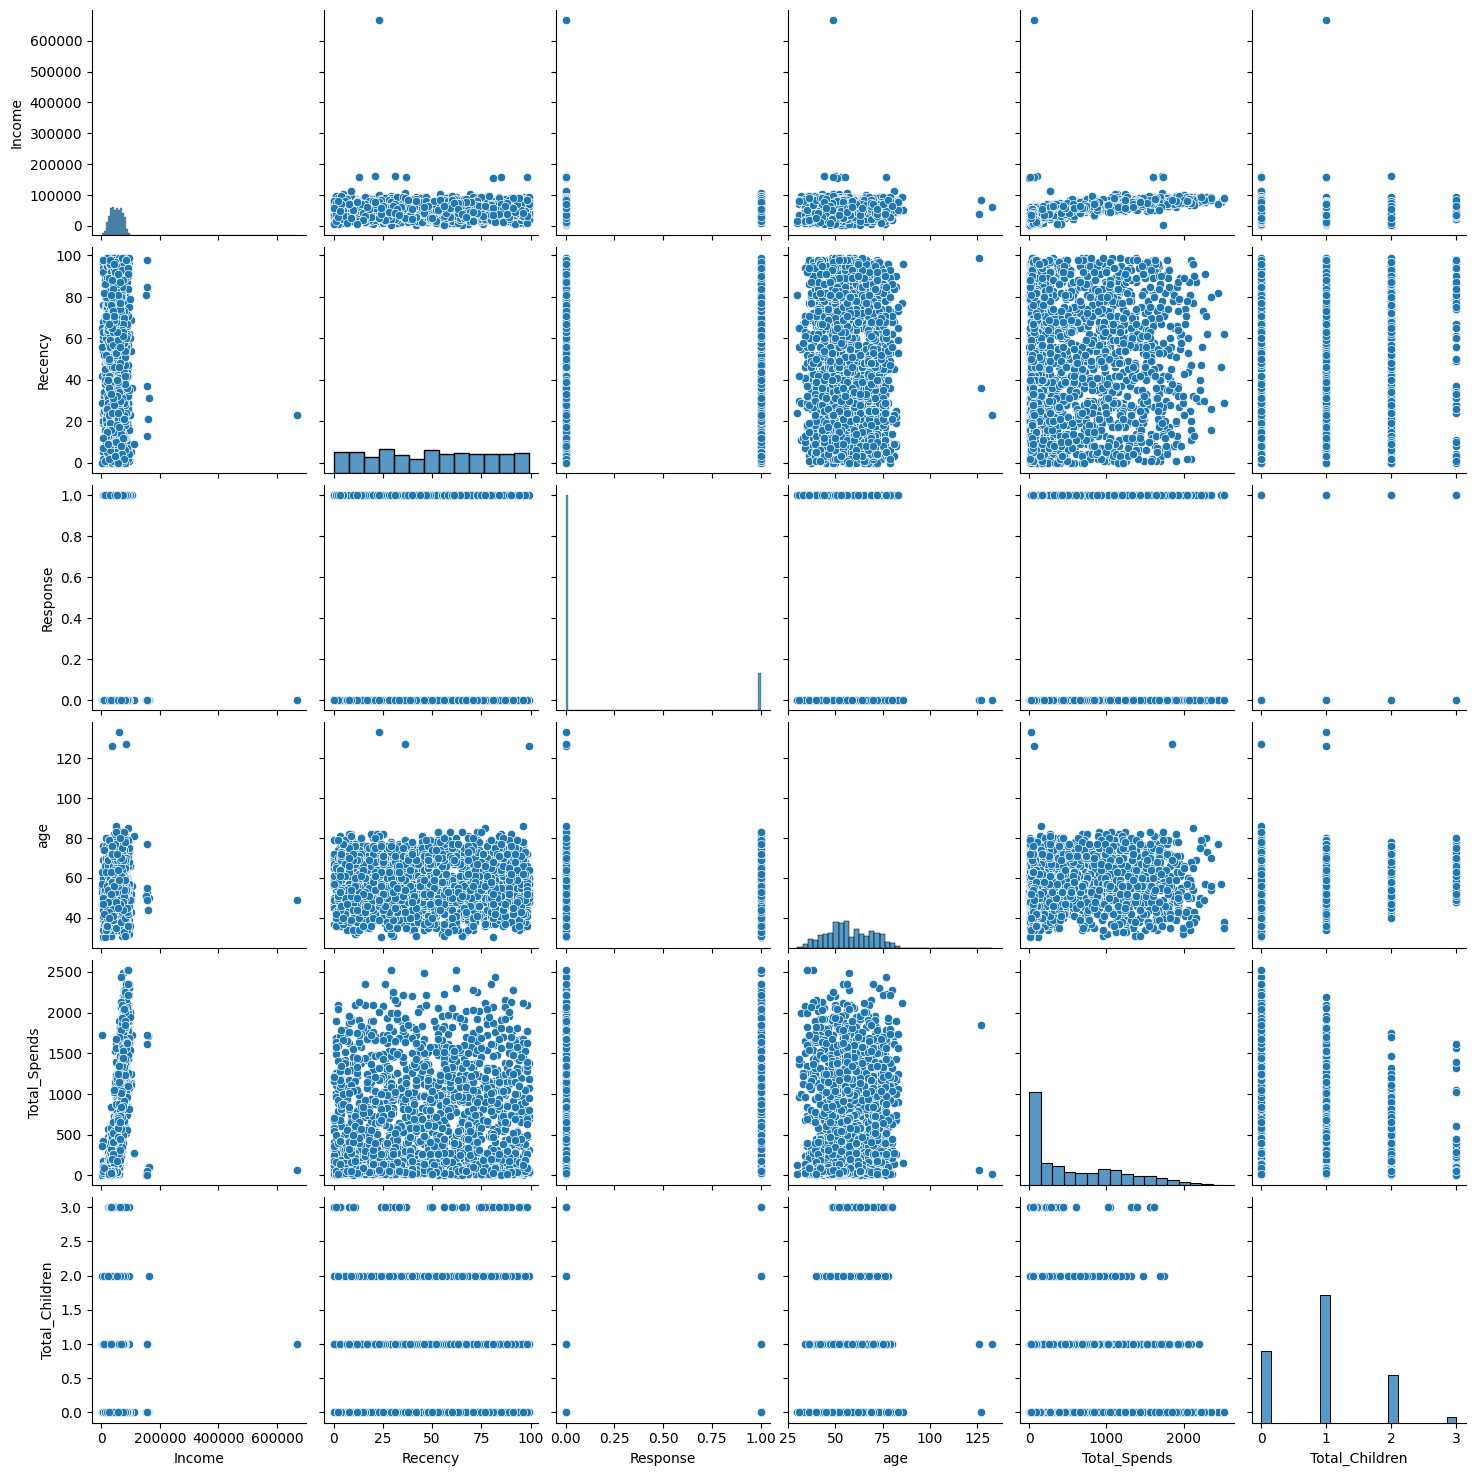

In [32]:
cols = ["Income", "Recency", "Response", "age", "Total_Spends", "Total_Children"]

# relative plots of some features-  pair plots
sns.pairplot(df_cleaned[cols])

In [34]:
print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


## Heatmap

<Axes: >

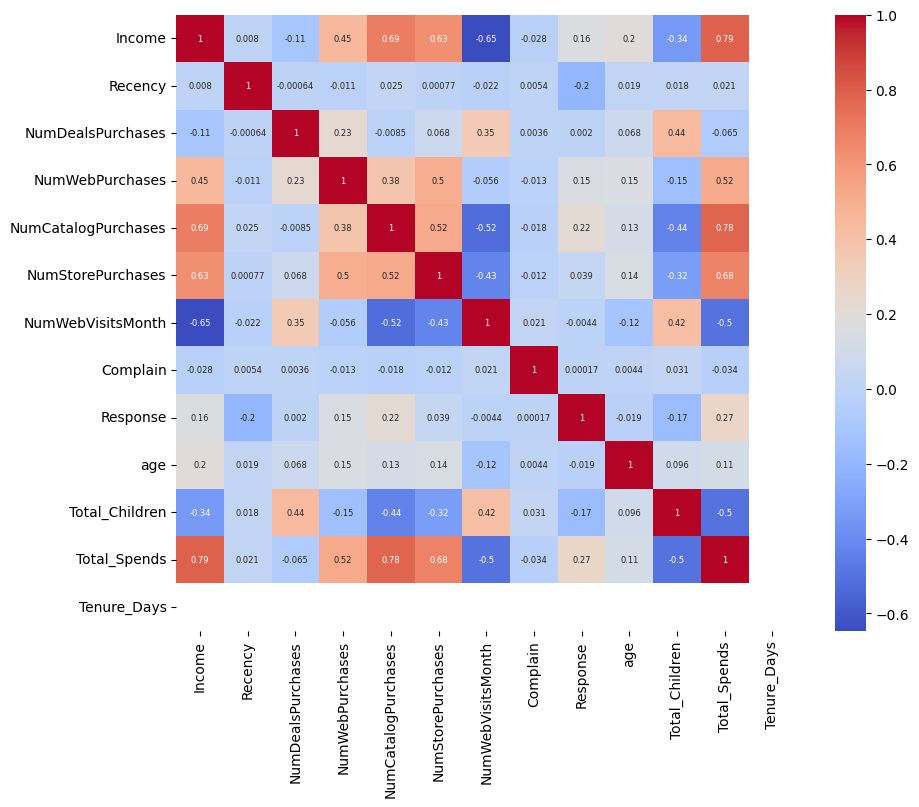

In [36]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size" : 6},
    cmap='coolwarm'
)

## Encoding

In [40]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ['Education', 'Living_With']

encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [41]:
enc_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [44]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [45]:
df_encoded.shape

(2236, 18)

In [46]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Total_Children,Total_Spends,Tenure_Days,Education_Graduate,Education_Post Graduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,0,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,2,27,0,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,0,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,1,53,0,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,1,422,0,0.0,1.0,0.0,0.0,1.0


## Feature Scaling

In [47]:
X = df_encoded

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualize